<a href="https://colab.research.google.com/github/snazziwa/Phishing-detection/blob/main/Phishing_Email_Detection_ipynb_with_CEAS_08_csv_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding,GRU,LSTM,Bidirectional,SimpleRNN
from tensorflow.keras.utils import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential # Changed from keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout # Changed from keras.layers import Dense,Dropout
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/My Drive/Colab Notebooks/CEAS_08.csv"
df = pd.read_csv(file_path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
#text preprocessing
df.isnull().sum()

,0
sender,0
receiver,462
date,0
subject,28
body,0
label,0
urls,0


In [ ]:
#dropping duplicate and null values
# Drop the extra index column
df.drop(columns=["Unnamed: 0"], errors='ignore', inplace=True)

# Remove rows with null values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check the cleaned dataframe
df.head()


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
print("Dimension of the row data:",df.shape)

Dimension of the row data: (38669, 7)


In [ ]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
# Create the bar chart
import plotly.express as px
import plotly.express as px

# Count phishing vs safe emails
label_counts = df['label'].value_counts()

# Map numeric labels to meaningful names (adjust if needed)
label_mapping = {
    0: "Safe Email",
    1: "Phishing Email"
}

# Apply mapping
label_counts.index = label_counts.index.map(label_mapping)

# Create bar chart
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    text=label_counts.values,
    labels={
        'x': 'Email Category',
        'y': 'Number of Emails'
    },
    title="Distribution of Safe vs Phishing Emails<br><sup>CEAS Phishing Email Dataset</sup>"
)

# Improve readability
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title="Email Type",
    yaxis_title="Email Count",
    showlegend=False
)

fig.show()

#Labeled the email types (phishing email and safe email) based on the 'label' column in the dataset. 0 = safe / 1 = phishing

In [ ]:
# Create the pie chart
import plotly.express as px

# Count labels
label_counts = df['label'].value_counts()

# Map labels to readable names
label_mapping = {
    0: "Safe Email",
    1: "Phishing Email"
}

label_counts.index = label_counts.index.map(label_mapping)

# Create the pie chart
fig_pie = px.pie(
    names=label_counts.index,
    values=label_counts.values,
    title="Distribution of Safe vs Phishing Emails<br><sup>CEAS Phishing Email Dataset</sup>"
)

# Improve readability
fig_pie.update_traces(textinfo='percent+label')

# Show the plot
fig_pie.show()


In [ ]:
#Label Handling & Feature Selection (CEAS Dataset)
# Target variable (already integer encoded)
# 0 = Safe Email
# 1 = Phishing Email
y = df['label']

# Optional: create readable labels (for plots / analysis)
df['Email_Type_Name'] = df['label'].map({
    0: 'Safe Email',
    1: 'Phishing Email'
})

# Feature columns for model input
X = df[['subject', 'body', 'urls']]


In [ ]:
import re

def preprocess_text(text):
    if not isinstance(text, str):
        text = ""

    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    text = text.lower()                      # lowercase
    text = re.sub(r'\s+', ' ', text).strip() # clean spaces

    return text

df['Email Text'] = df['subject'].astype(str) + " " + df['body'].astype(str)
df['Email Text'] = df['Email Text'].apply(preprocess_text)


In [ ]:
df

,sender,receiver,date,subject,body,label,urls,Email_Type_Name,Email Text
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,Phishing Email,never agree to be a loser buck up your trouble...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,Phishing Email,befriend jenna jameson upgrade your sex and pl...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,Phishing Email,cnncom daily top 10 the daily top 10 from cnnc...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,Safe Email,re svn commit r619753 in spamassassintrunk lib...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,Phishing Email,specialpricespharmmoreinfo welcomefastshipping...
...,...,...,...,...,...,...,...,...,...
39149,CNN Alerts <charlene-detecton@btcmarketing.com>,email1007@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:34:50 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0,Phishing Email,cnn alerts my custom alert cnn alerts my custo...
39150,CNN Alerts <idgetily1971@careplusnj.org>,email104@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 10:35:11 -0400",CNN Alerts: My Custom Alert,\n\nCNN Alerts: My Custom Alert\n\n\n\n\n\n\n ...,1,0,Phishing Email,cnn alerts my custom alert cnn alerts my custo...
39151,Abhijit Vyas <xpojhbz@gmail.com>,fxgmqwjn@triptracker.net,"Fri, 08 Aug 2008 22:00:43 +0800",Slideshow viewer,Hello there ! \nGreat work on the slide show v...,0,0,Safe Email,slideshow viewer hello there great work on the...
39152,Joseph Brennan <vupzesm@columbia.edu>,zqoqi@spamassassin.apache.org,"Fri, 08 Aug 2008 09:00:46 -0500",Note on 2-digit years,"\nMail from sender , coming from intuit.com\ns...",0,0,Safe Email,note on 2digit years mail from sender coming f...


In [ ]:
import re

# Target variable (already integer encoded)
# 0 = Safe Email
# 1 = Phishing Email
y = df['label']

# Optional: readable labels
df['Email_Type_Name'] = df['label'].map({
    0: 'Safe Email',
    1: 'Phishing Email'
})

# Feature columns
X = df[['subject', 'body', 'urls']]

# Text preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        text = ""

    # Remove hyperlinks
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Combine subject and body
df['Email Text'] = df['subject'].astype(str) + " " + df['body'].astype(str)

# Apply preprocessing
df['Email Text'] = df['Email Text'].apply(preprocess_text)


In [ ]:
df.head()

,sender,receiver,date,subject,body,label,urls,Email_Type_Name,Email Text
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,Phishing Email,never agree to be a loser buck up your trouble...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,Phishing Email,befriend jenna jameson upgrade your sex and pl...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,Phishing Email,cnncom daily top 10 the daily top 10 from cnnc...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,Safe Email,re svn commit r619753 in spamassassintrunk lib...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,Phishing Email,specialpricespharmmoreinfo welcomefastshipping...


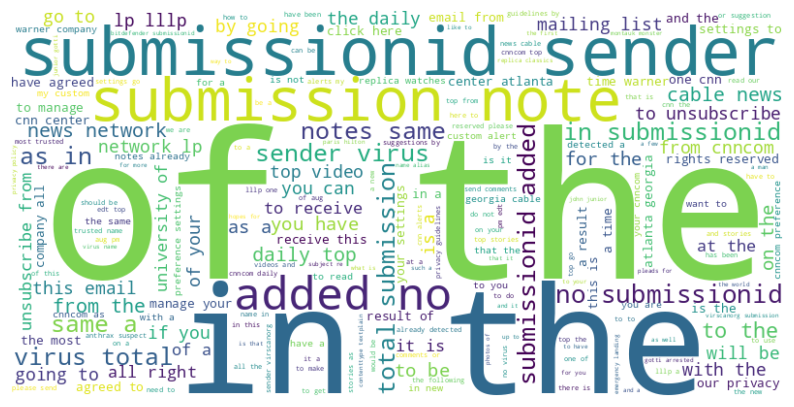

In [ ]:
#Wordcloud of available stopwords. ....... the most common words that appear across all emails in your dataset after preprocessing.
from wordcloud import WordCloud

#combine all rows into a single string
all_mails = " ".join(df['Email Text'])

#create a wordcloud object
word_cloud = WordCloud(stopwords="english",width=800,height=400,background_color='white').generate(all_mails)

plt.figure(figsize=(10,6))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis("off")
plt.show()

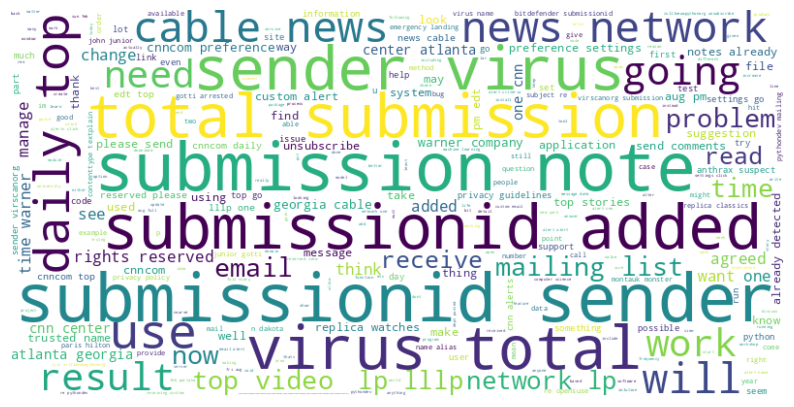

In [ ]:
#Wordcloud of unique words
#combine all rows into a single string
all_mails = " ".join(df['Email Text'])

#create a wordcloud object
word_cloud = WordCloud(width=800,height=400,background_color='white',max_words=10000).generate(all_mails)
plt.figure(figsize=(10,6))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
#Converting test into vector
#TFI-DF Vectorizsation
tf = TfidfVectorizer(stop_words="english",max_features=10000) #dimension reduction

feature_x = tf.fit_transform(df["Email Text"]).toarray()

In [ ]:
y_tf = np.array(df['label']) # convert the label into numpy array

In [ ]:
#The dataset was divided into training (80%) and testing (20%) subsets to evaluate model performance.
#The training set was used to allow the model to learn patterns from the email features, while the testing set was reserved for evaluation on unseen data.
#The parameter `random_state=0` was used to ensure that the data split remains consistent across runs, allowing the results to be reproducible.

#Splitting into train and test sets
x_train,x_test,y_train,y_test = train_test_split(feature_x,y_tf,train_size=0.8,random_state=0)

In [ ]:
#What the model is doing conceptually: It looks at the words in emails
#Learns how often each word appears in phishing vs safe emails Uses conditional probability to estimate:
#“Given these words, how likely is this email phishing?”

#Applying different algoritmns
#Naive Bayes
#naive bayes works with condtional probability
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train,y_train)

MultinomialNB()

accuracy from native bayes: 98.07 %
f1 score from naive bayes: 98.27 %
classification report :

               precision    recall  f1-score   support

           0       0.96      0.99      0.98      3363
           1       1.00      0.97      0.98      4371

    accuracy                           0.98      7734
   macro avg       0.98      0.98      0.98      7734
weighted avg       0.98      0.98      0.98      7734



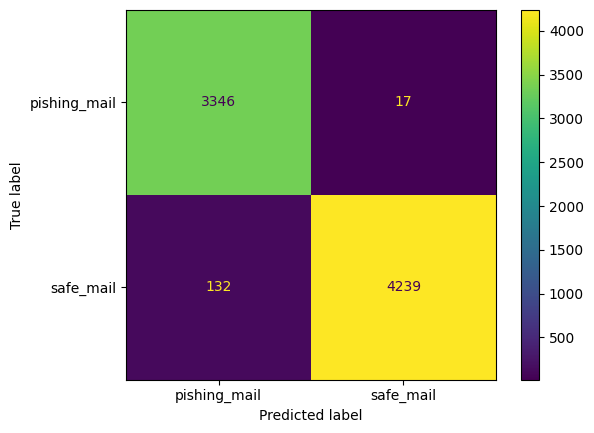

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay,confusion_matrix
pred_nav = nb.predict(x_test)

# Checking the performance

print(f"accuracy from native bayes: {accuracy_score(y_test,pred_nav)*100:.2f} %")
print(f"f1 score from naive bayes: {f1_score(y_test,pred_nav)*100:.2f} %")
print("classification report :\n\n",classification_report(y_test,pred_nav))

#confusion matrix: visual table showing how many emails were correctly or incorrectly predicted for each class.
clf_nav = confusion_matrix(y_test,pred_nav)
cx_ = ConfusionMatrixDisplay(clf_nav,display_labels=['pishing_mail','safe_mail']).plot()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


accuracy from logistic regression:99.43 %
f1 score from logistic regression: 99.50 %
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3363
           1       0.99      1.00      0.99      4371

    accuracy                           0.99      7734
   macro avg       0.99      0.99      0.99      7734
weighted avg       0.99      0.99      0.99      7734



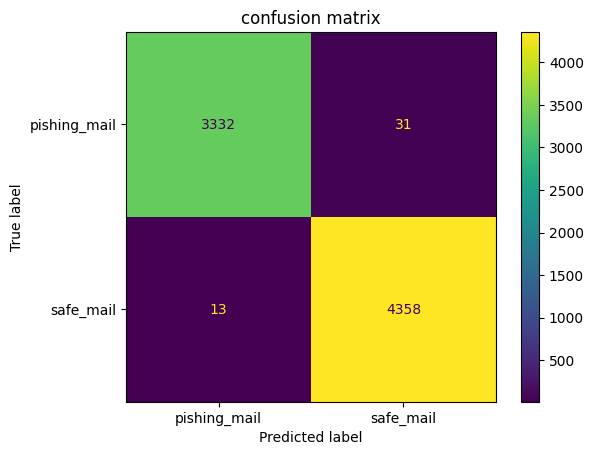

In [ ]:
#Logistic Regression
lg = LogisticRegression()
lg.fit(x_train,y_train)  #Trains it on x_train (email features) and y_train (labels: safe vs phishing).
#The model learns a linear relationship between features (words) and the probability that an email is phishing


# prediction
pred_lg = lg.predict(x_test)
# performance
print("")
print(f"accuracy from logistic regression:{accuracy_score(y_test,pred_lg)*100:.2f} %")
print(f"f1 score from logistic regression: {f1_score(y_test,pred_lg)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_lg))

clf_lg = confusion_matrix(y_test,pred_lg)
cx_ = ConfusionMatrixDisplay(clf_lg,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

In [ ]:
# save the model for future use

import joblib

# Save the trained model to a file
joblib.dump(nb, 'email_spam_nb.pkl')

['email_spam_nb.pkl']

accuracy from logistic regression:99.53 %
f1 score from logistic regression: 99.59 %
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3363
           1       0.99      1.00      1.00      4371

    accuracy                           1.00      7734
   macro avg       1.00      1.00      1.00      7734
weighted avg       1.00      1.00      1.00      7734



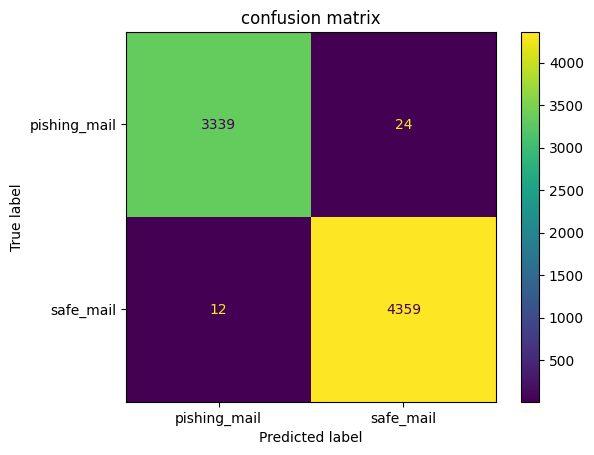

In [ ]:
#SGD Classifier
from sklearn.linear_model import SGDClassifier

# passing object
sgd = SGDClassifier()
sgd.fit(x_train,y_train)

# prediction
pred_sgd = sgd.predict(x_test)
# performance
print(f"accuracy from logistic regression:{accuracy_score(y_test,pred_sgd)*100:.2f} %")
print(f"f1 score from logistic regression: {f1_score(y_test,pred_sgd)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_sgd))

clf_sgd = confusion_matrix(y_test,pred_sgd)
cx_ = ConfusionMatrixDisplay(clf_sgd,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

accuracy from XGB:99.31 %
f1 score from XGB: 99.40 %
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3363
           1       0.99      1.00      0.99      4371

    accuracy                           0.99      7734
   macro avg       0.99      0.99      0.99      7734
weighted avg       0.99      0.99      0.99      7734



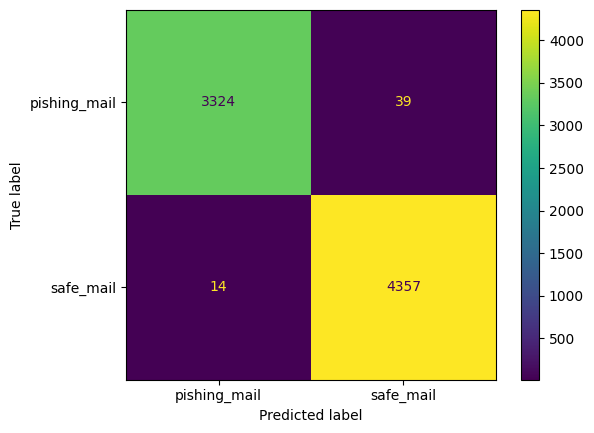

In [ ]:
#XGBoost
# applying boosting algorithm
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

#prediction
pred_xgb = xgb.predict(x_test)

#performance
print(f"accuracy from XGB:{accuracy_score(y_test,pred_xgb)*100:.2f} %")
print(f"f1 score from XGB: {f1_score(y_test,pred_xgb)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_xgb))

#confusion matrix
clf_xgb = confusion_matrix(y_test,pred_xgb)
cx_ = ConfusionMatrixDisplay(clf_xgb,display_labels=['pishing_mail','safe_mail']).plot()
plt.show()

accuracy from Decision Tree:98.72 %
f1 score from Decision Tree: 98.87 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3363
           1       0.99      0.99      0.99      4371

    accuracy                           0.99      7734
   macro avg       0.99      0.99      0.99      7734
weighted avg       0.99      0.99      0.99      7734



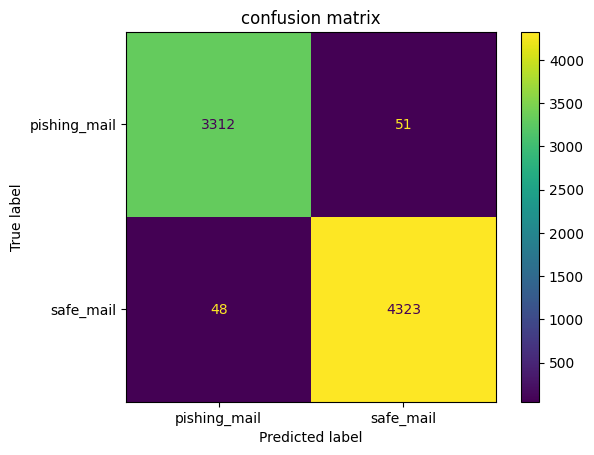

In [ ]:
#Decision Tree
dtr = DecisionTreeClassifier() #passing object
dtr.fit(x_train,y_train)

#prediction
pred_dtr = dtr.predict(x_test)

#performance
print(f"accuracy from Decision Tree:{accuracy_score(y_test,pred_dtr)*100:.2f} %")
print(f"f1 score from Decision Tree: {f1_score(y_test,pred_dtr)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_dtr))

#confusion matrix
clf_dtr = confusion_matrix(y_test,pred_dtr)
cx_ = ConfusionMatrixDisplay(clf_dtr,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

accuracy from rnadom forest:99.52 %
f1 score from random forest: 99.58 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3363
           1       1.00      1.00      1.00      4371

    accuracy                           1.00      7734
   macro avg       1.00      1.00      1.00      7734
weighted avg       1.00      1.00      1.00      7734



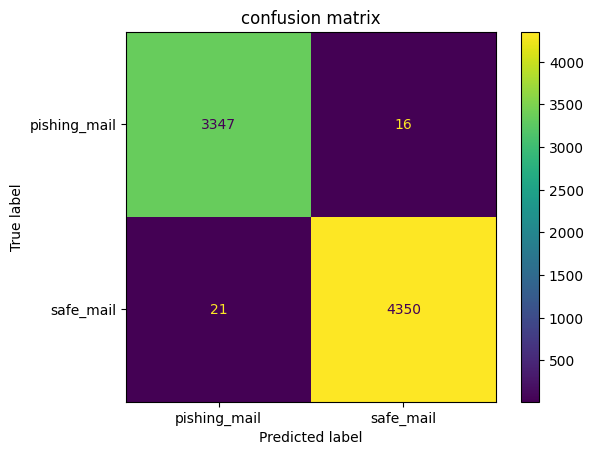

In [ ]:
#Random Forest
rnf = RandomForestClassifier() #passing object
rnf.fit(x_train,y_train)

#prediction
pred_rnf = rnf.predict(x_test)

#performance
print(f"accuracy from rnadom forest:{accuracy_score(y_test,pred_rnf)*100:.2f} %")
print(f"f1 score from random forest: {f1_score(y_test,pred_rnf)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_rnf))

#confusion matrix
clf_rnf = confusion_matrix(y_test,pred_rnf)
cx_ = ConfusionMatrixDisplay(clf_rnf,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

accuracy from MLP:99.70 %
f1 score from MLP: 99.74 %
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      3363
           1       1.00      1.00      1.00      4371

    accuracy                           1.00      7734
   macro avg       1.00      1.00      1.00      7734
weighted avg       1.00      1.00      1.00      7734



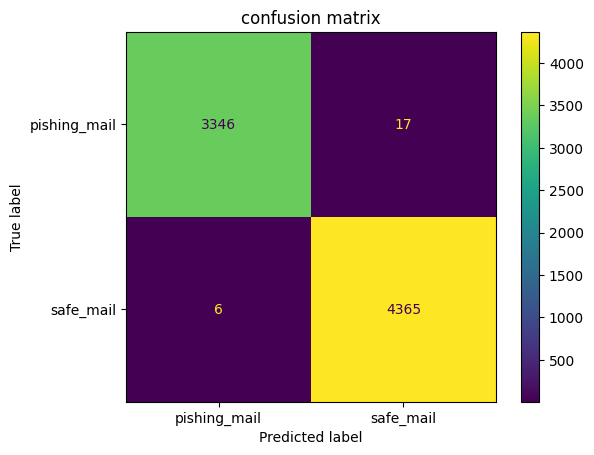

In [ ]:
#MLP Classifier(Multi-layer perceptios)
mlp = MLPClassifier()  # passing object
mlp.fit(x_train,y_train)

#prediction
pred_mlp = mlp.predict(x_test)

#performance
print(f"accuracy from MLP:{accuracy_score(y_test,pred_mlp)*100:.2f} %")
print(f"f1 score from MLP: {f1_score(y_test,pred_mlp)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_mlp))

#confusion matrix
clf_mlp = confusion_matrix(y_test,pred_mlp)
cx_ = ConfusionMatrixDisplay(clf_mlp,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

In [ ]:
#EDA comparison of the models performances
models = ['Naive bayes', 'Logistic Regression', 'SGD Classifier', 'XGBoost', 'Decision Tree', 'Random Forest', 'MLPClassifier']
accuracies = [97.52, 97.95, 98.57, 97.21, 93.67, 97.72, 98.29]

# Create the bar chart
fig = px.bar(x=models, y=accuracies, labels={'x': 'Models', 'y': 'Accuracy'},
             title="Performance of the models", text=accuracies)

# Customize the layout (optional)
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside', marker_color='magenta')

# Show the plot
fig.show()

In [ ]:
#prepping text so a Neural Network can actually understand it.
#turned emails → numbers → equal-length vectors so a neural network can learn patterns like phishing vs safe emails
#NN (Neural Network)
max_len = 150

tk = Tokenizer()

# Process the text

tk.fit_on_texts(df['Email Text'])
sequences = tk.texts_to_sequences(df['Email Text'])
vector = pad_sequences(sequences,padding='post', maxlen=max_len)

In [ ]:
len(vector)

38669

In [ ]:
x = np.array(vector)
y = np.array(df["label"])

#Neural Networks cannot read text. They only understand numbers.
#So this whole block is about converting emails (words) into numbers

In [ ]:
#Simple RNN
model_smp = Sequential() # Sequential() API
model_smp.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_smp.add(SimpleRNN(units=100))
model_smp.add(Dropout(0.45))
model_smp .add(Dense(1, activation='sigmoid'))

In [ ]:
#Split the dataset into train and test set

x_train, x_test, y_train, y_test = train_test_split(vector, df['label'], test_size=0.2, random_state =0)

In [ ]:
model_smp.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [ ]:
model_smp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historical_smp  = model_smp.fit(x_train,y_train, epochs=7, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.7574 - loss: 0.5089 - val_accuracy: 0.8067 - val_loss: 0.4836
Epoch 2/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8038 - loss: 0.4436 - val_accuracy: 0.9079 - val_loss: 0.2553
Epoch 3/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7961 - loss: 0.4689 - val_accuracy: 0.8214 - val_loss: 0.3347
Epoch 4/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8215 - loss: 0.3582 - val_accuracy: 0.8159 - val_loss: 0.3672
Epoch 5/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7974 - loss: 0.3752 - val_accuracy: 0.8210 - val_loss: 0.3582
Epoch 6/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8008 - loss: 0.3891 - val_accuracy: 0.8170 - val_loss: 0.4224
Epoch 7/7
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8103 - loss: 0.4116 - val_accuracy: 0.8179 - val_loss: 0.3632


Text(0, 0.5, 'Loss')

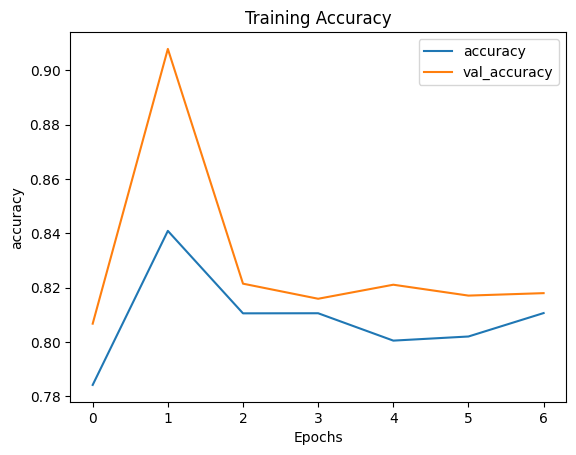

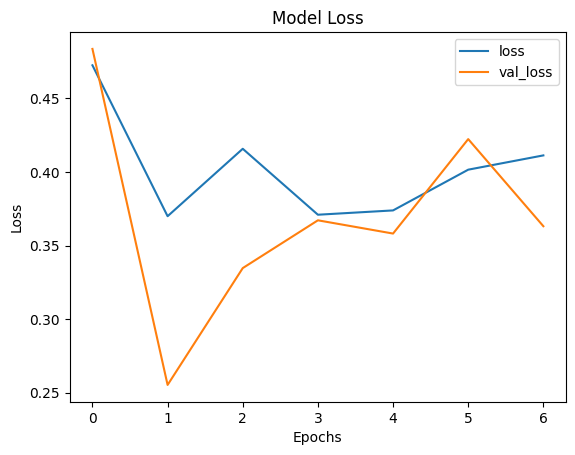

In [ ]:
import matplotlib.pyplot as plt
pd.DataFrame(historical_smp.history)

pd.DataFrame(historical_smp.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(historical_smp.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


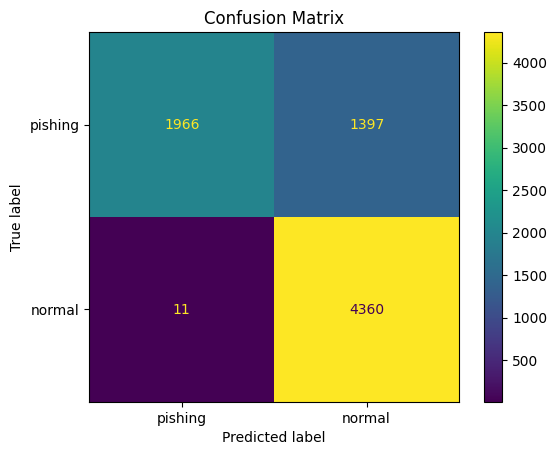

In [ ]:
y_pred_prob_smp = model_smp.predict(x_test)
y_pred_smp = (y_pred_prob_smp > 0.5).astype(int)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cnf_smp = confusion_matrix(y_test,y_pred_smp)
ax_smp = ConfusionMatrixDisplay(confusion_matrix=cnf_smp,display_labels=['pishing','normal']).plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#LSTM Architecture
model = Sequential() # Sequential() API
model.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model.add(LSTM(units=100))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historical  = model.fit(x_train,y_train, epochs=5, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/5
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8771 - loss: 0.2859 - val_accuracy: 0.9853 - val_loss: 0.0602
Epoch 2/5
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9859 - loss: 0.0519 - val_accuracy: 0.9928 - val_loss: 0.0269
Epoch 3/5
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9950 - loss: 0.0223 - val_accuracy: 0.9956 - val_loss: 0.0178
Epoch 4/5
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 0.9957 - val_loss: 0.0186
Epoch 5/5
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9985 - loss: 0.0081 - val_accuracy: 0.9951 - val_loss: 0.0210


In [ ]:
#Performance
results = model.evaluate(x_test, y_test)
loss = results[0]  # Extract the loss from the results
accuracy = results[1]  # Extract the accuracy from the results

print(f"Model Loss: {loss}")
print(f"Model Accuracy: {accuracy*100}")

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9951 - loss: 0.0233
Model Loss: 0.021047189831733704
Model Accuracy: 99.50866103172302


In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Text(0, 0.5, 'Loss')

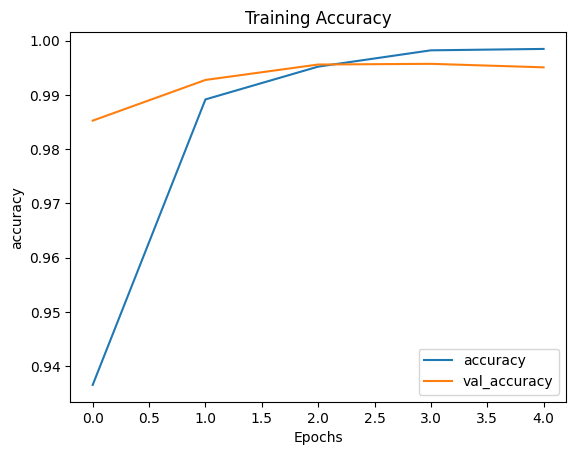

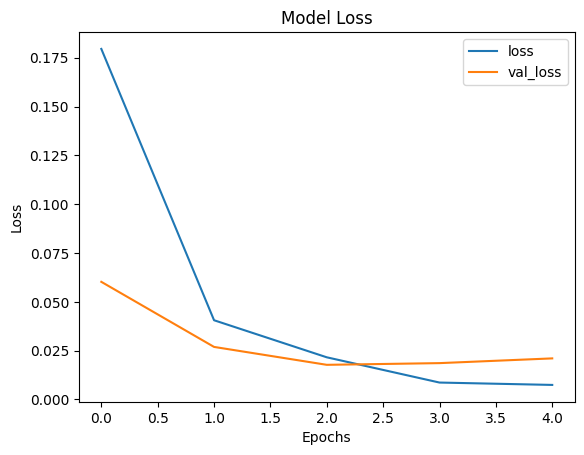

In [ ]:
pd.DataFrame(historical.history)

pd.DataFrame(historical.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(historical.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

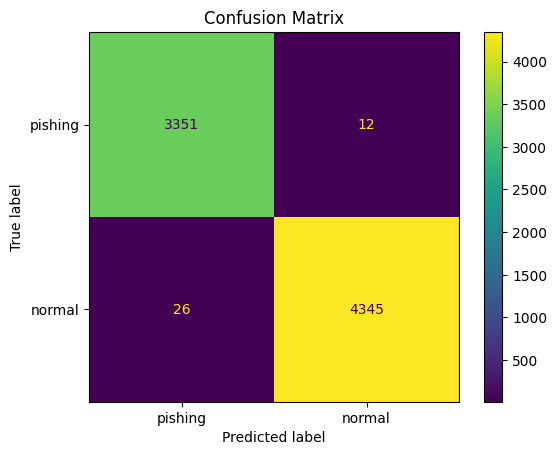

In [ ]:
cnf = confusion_matrix(y_test,y_pred)
ax = ConfusionMatrixDisplay(confusion_matrix=cnf,display_labels=['pishing','normal'])
ax.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Bidirectional
model_bi = Sequential() # Sequential() API
model_bi.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_bi.add(Bidirectional(LSTM(units=100)))
model_bi.add(Dropout(0.5))
model_bi.add(Dense(1, activation='sigmoid'))

In [ ]:
model_bi.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])

In [ ]:
model_bi.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historical  = model_bi.fit(x_train,y_train, epochs=2, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/2
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9474 - loss: 0.1394 - val_accuracy: 0.9950 - val_loss: 0.0206
Epoch 2/2
1934/1934 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9947 - loss: 0.0201 - val_accuracy: 0.9965 - val_loss: 0.0152


In [ ]:
results_bi = model_bi.evaluate(x_test, y_test)
loss_bi = results_bi[0]
accuracy_bi = results_bi[1]

print(f"Model Loss: {loss_bi}")
print(f"Model Accuracy: {accuracy_bi*100:.2f}%")

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9946 - loss: 0.0240
Model Loss: 0.015150964260101318
Model Accuracy: 99.65%


In [ ]:
y_pred_prob_bi = model_bi.predict(x_test)
y_pred_bi = (y_pred_prob_bi > 0.5).astype(int)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


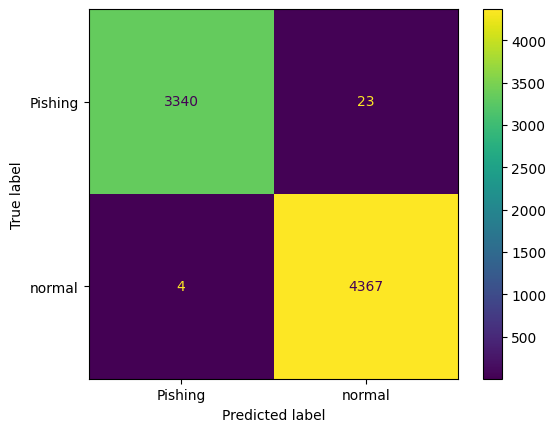

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cnf_bi = confusion_matrix(y_test,y_pred_bi)
ax_bi = ConfusionMatrixDisplay(confusion_matrix=cnf_bi,display_labels=['Pishing','normal'])
ax_bi.plot()
plt.show()

In [ ]:
#GRU (Gated Recurrent Unit)
model_gru = Sequential() # Sequential() API
model_gru.add(Embedding(input_dim=len(tk.word_index)+1,output_dim=50,input_length=150))
model_gru.add(GRU(units=100))
model_gru.add(Dropout(0.5))
model_gru.add(Dense(1, activation='sigmoid'))

In [ ]:
model_gru.compile(loss='binary_crossentropy' , optimizer='adam', metrics=['accuracy'])
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_gru.fit(x_train,y_train, epochs=3, batch_size=16, validation_data=(x_test,y_test))

Epoch 1/3
1121/1934 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8443 - loss: 0.3635

In [ ]:
y_pred_prob_gru = model_gru.predict(x_test)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


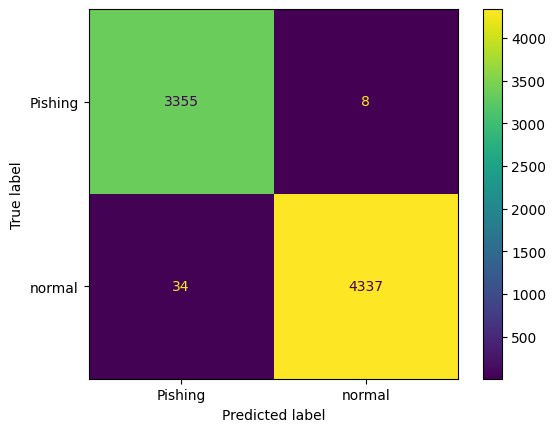

In [ ]:
cnf_gru = confusion_matrix(y_test,y_pred_gru)
ax_gru = ConfusionMatrixDisplay(confusion_matrix=cnf_gru,display_labels=['Pishing','normal'])
ax_gru.plot()
plt.show()